<a href="https://colab.research.google.com/github/hyeonggyeong-kim/comprehensive-project/blob/khg/ml/preprocessing_and_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

라이브러리 로드 완료
✅ 통합 주행 데이터: (25008, 29)
✅ 주행 정보 1: (1324, 29)
✅ 주행 정보 2: (1060, 29)
✅ 주행 정보 3: (827, 29)
✅ 주행 정보 4: (944, 29)
✅ 개별 주행 통합: (4155, 29)
✅ 난폭운전 데이터: (6000, 17)
컬럼명 표준화 완료
표준화된 컬럼(통합주행): ['TIMESTAMP', 'Lat.', 'Lon.', 'SPEED', 'ENGINE_RPM', 'TIMING_ADVANCE', 'THROTTLE_POS', '연료 레일 압력', '공기량 (MAF) 센서', '연료 잔여량', '엔진 기준 토크', 'ENGINE_LOAD', '흡기 매니폴드 절대 압력 (MAP)', '엔진 오일 온도', 'ENGINE_COOLANT_TEMP', '연료 단기 보정 (뱅크1)', '연료 단기 보정 (뱅크2)', '연료 장기 보정 (뱅크1)', '연료 장기 보정 (뱅크2)', '외부 공기 온도', '대기압 압력', '하이브리드/EV 배터리 팩 잔여 충전량', '미립자 필터 (PF) 델타 압력 (뱅크1)', '미립자 필터 (PF) 입구 온도 (뱅크1)', 'AIR_INTAKE_TEMP', '배기 가스 온도 (뱅크1 센서1)', '배기 가스 온도 (뱅크2 센서1)', '제어 모듈 전압', 'DATA_SOURCE']
통합 주행 전처리 후:  (25008, 9)
개별 주행 전처리 후:  (4155, 9)
난폭운전 전처리 후:   (6000, 9)

결측치 확인:
TIMESTAMP              0
SPEED                  0
ENGINE_RPM             0
THROTTLE_POS           0
ENGINE_LOAD            0
ENGINE_COOLANT_TEMP    0
AIR_INTAKE_TEMP        0
TIMING_ADVANCE         0
DATA_SOURCE            0
dtype: int64
피처 엔지니어링 완료 

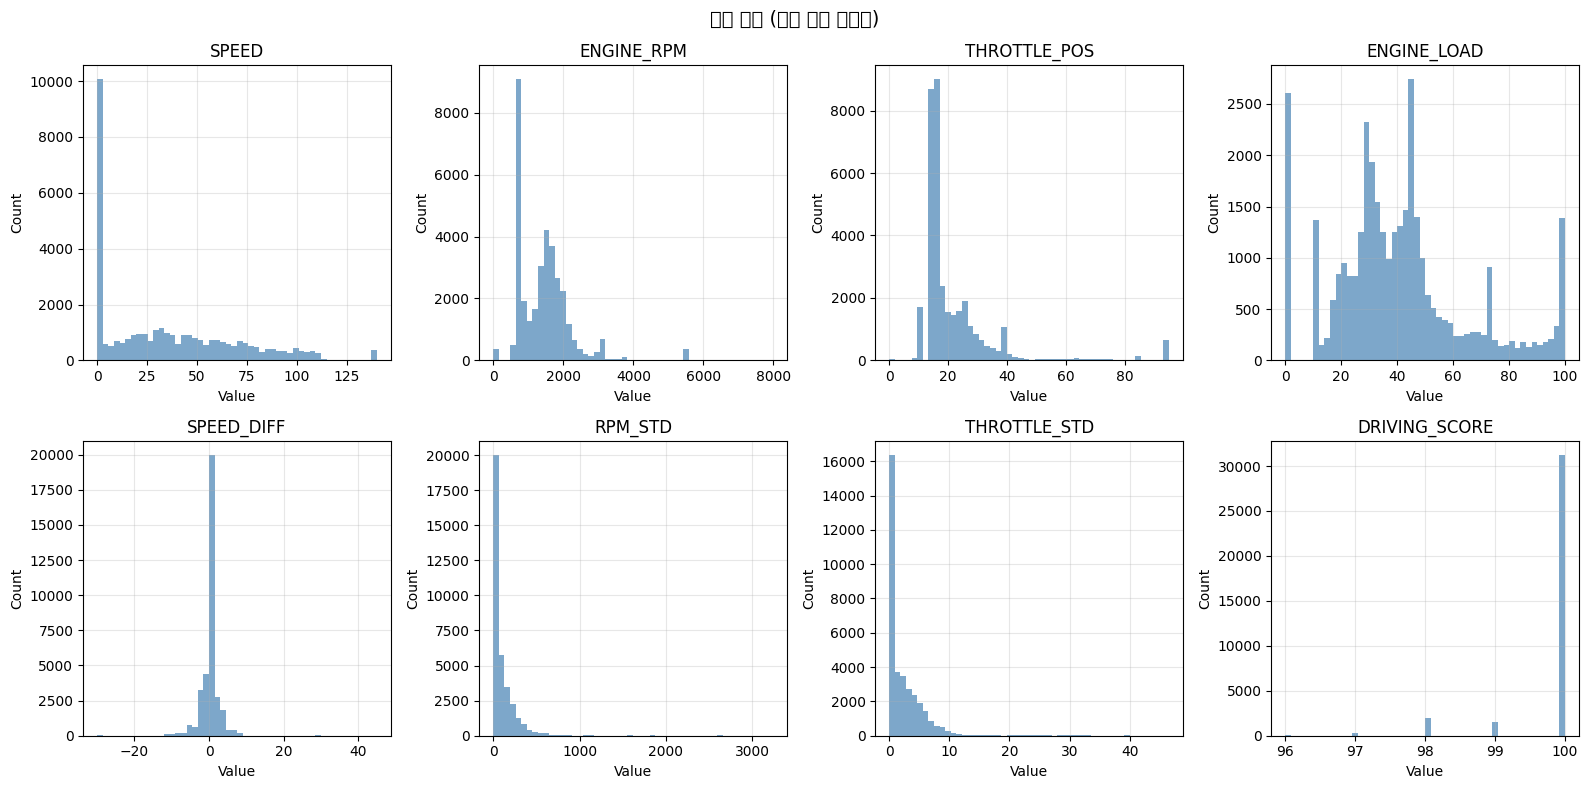

저장 완료: /content/sample_data/obd_all_merged.csv
최종 데이터 크기: (35163, 17)

피처 목록 (15개):
   1. SPEED
   2. ENGINE_RPM
   3. THROTTLE_POS
   4. ENGINE_LOAD
   5. ENGINE_COOLANT_TEMP
   6. AIR_INTAKE_TEMP
   7. TIMING_ADVANCE
   8. SPEED_DIFF
   9. RPM_DIFF
  10. THROTTLE_DIFF
  11. SPEED_MA
  12. RPM_MA
  13. THROTTLE_MA
  14. RPM_STD
  15. THROTTLE_STD
  16. DRIVING_SCORE


In [4]:
# OBD-II 데이터 전처리 및 피처 엔지니어링

## PART 1. 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

!pip install xlrd -q

print('라이브러리 로드 완료')
## PART 2. 데이터 로드
# 통합 주행 데이터
df_real = pd.read_excel('/content/sample_data/통합_주행정보.xlsx')
df_real['DATA_SOURCE'] = 'real_unified'
print(f'✅ 통합 주행 데이터: {df_real.shape}')

# 개별 주행 데이터 1~4 (헤더가 2번째 행)
real_dfs = []
for i in range(1, 5):
    try:
        tmp = pd.read_excel(f'/content/sample_data/주행 정보 {i}.xls', engine='xlrd', header=1)
        tmp['DATA_SOURCE'] = f'real_{i}'
        real_dfs.append(tmp)
        print(f'✅ 주행 정보 {i}: {tmp.shape}')
    except Exception as e:
        print(f'⚠️ 주행 정보 {i} 로드 실패: {e}')

df_indiv = pd.concat(real_dfs, ignore_index=True) if real_dfs else pd.DataFrame()
print(f'✅ 개별 주행 통합: {df_indiv.shape}')

# 난폭운전 데이터
df_aggressive = pd.read_excel('/content/sample_data/난폭운전_전용_대용량_데이터셋.xlsx')
df_aggressive['DATA_SOURCE'] = 'aggressive'
print(f'✅ 난폭운전 데이터: {df_aggressive.shape}')
## PART 3. 컬럼명 표준화 (한글 → 영어)
COL_MAP = {
    '시간':                    'TIMESTAMP',
    '차량 속도 센서':           'SPEED',
    '엔진 회전수':              'ENGINE_RPM',
    '스로틀 위치 절대값':        'THROTTLE_POS',
    '엔진 부하':                'ENGINE_LOAD',
    '엔진 냉각 온도':            'ENGINE_COOLANT_TEMP',
    '흡입 공기 온도 (IAT)':     'AIR_INTAKE_TEMP',
    '액셀러레이터 페달 위치 D':  'TIMING_ADVANCE',
}

def rename_cols(df):
    return df.rename(columns=COL_MAP)

df_real       = rename_cols(df_real)
df_indiv      = rename_cols(df_indiv)
df_aggressive = rename_cols(df_aggressive)

print('컬럼명 표준화 완료')
print('표준화된 컬럼(통합주행):', df_real.columns.tolist())
## PART 4. 전처리
CORE_COLS = [
    'TIMESTAMP', 'SPEED', 'ENGINE_RPM', 'THROTTLE_POS',
    'ENGINE_LOAD', 'ENGINE_COOLANT_TEMP', 'AIR_INTAKE_TEMP',
    'TIMING_ADVANCE', 'DATA_SOURCE'
]

def preprocess(df):
    available = [c for c in CORE_COLS if c in df.columns]
    df = df[available].copy()
    numeric_cols = [c for c in available if c not in ['TIMESTAMP', 'DATA_SOURCE']]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'SPEED' in df.columns:
        df.loc[df['SPEED'] < 0, 'SPEED'] = np.nan
        df.loc[df['SPEED'] > 300, 'SPEED'] = np.nan
    if 'ENGINE_RPM' in df.columns:
        df.loc[df['ENGINE_RPM'] < 0, 'ENGINE_RPM'] = np.nan
        df.loc[df['ENGINE_RPM'] > 8000, 'ENGINE_RPM'] = np.nan
    if 'THROTTLE_POS' in df.columns:
        df.loc[(df['THROTTLE_POS'] < 0) | (df['THROTTLE_POS'] > 100), 'THROTTLE_POS'] = np.nan

    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    return df.reset_index(drop=True)

df_real_clean       = preprocess(df_real)
df_indiv_clean      = preprocess(df_indiv)
df_aggressive_clean = preprocess(df_aggressive)

print(f'통합 주행 전처리 후:  {df_real_clean.shape}')
print(f'개별 주행 전처리 후:  {df_indiv_clean.shape}')
print(f'난폭운전 전처리 후:   {df_aggressive_clean.shape}')
print('\n결측치 확인:')
print(df_real_clean.isnull().sum())

## PART 5. 피처 엔지니어링
WINDOW = 5

def feature_engineering(df):
    df = df.copy()
    if 'SPEED' in df.columns:
        df['SPEED_DIFF'] = df['SPEED'].diff().fillna(0)
    if 'ENGINE_RPM' in df.columns:
        df['RPM_DIFF'] = df['ENGINE_RPM'].diff().fillna(0)
    if 'THROTTLE_POS' in df.columns:
        df['THROTTLE_DIFF'] = df['THROTTLE_POS'].diff().fillna(0)
    if 'SPEED' in df.columns:
        df['SPEED_MA'] = df['SPEED'].rolling(window=WINDOW, min_periods=1).mean()
    if 'ENGINE_RPM' in df.columns:
        df['RPM_MA'] = df['ENGINE_RPM'].rolling(window=WINDOW, min_periods=1).mean()
    if 'THROTTLE_POS' in df.columns:
        df['THROTTLE_MA'] = df['THROTTLE_POS'].rolling(window=WINDOW, min_periods=1).mean()
    if 'ENGINE_RPM' in df.columns:
        df['RPM_STD'] = df['ENGINE_RPM'].rolling(window=WINDOW, min_periods=1).std().fillna(0)
    if 'THROTTLE_POS' in df.columns:
        df['THROTTLE_STD'] = df['THROTTLE_POS'].rolling(window=WINDOW, min_periods=1).std().fillna(0)
    return df

df_real_fe       = feature_engineering(df_real_clean)
df_indiv_fe      = feature_engineering(df_indiv_clean)
df_aggressive_fe = feature_engineering(df_aggressive_clean)

fe_cols = [c for c in df_real_fe.columns if c not in ['TIMESTAMP', 'DATA_SOURCE']]
print(f'피처 엔지니어링 완료 | 피처 수: {len(fe_cols)}개')
print(f'피처 목록: {fe_cols}')
## PART 6. 운전 점수(DRIVING_SCORE) 생성
HARSH_ACCEL_THR = 5
HARSH_BRAKE_THR = -5
HIGH_RPM_THR    = 3000
HIGH_SPEED_THR  = 100

def add_driving_score(df):
    df = df.copy()
    speed_diff = df.get('SPEED_DIFF', pd.Series(0, index=df.index))
    rpm   = df.get('ENGINE_RPM', pd.Series(0, index=df.index))
    speed = df.get('SPEED',      pd.Series(0, index=df.index))
    penalty = (
        (speed_diff > HARSH_ACCEL_THR).astype(int) * 2 +
        (speed_diff < HARSH_BRAKE_THR).astype(int) * 2 +
        (rpm > HIGH_RPM_THR).astype(int) * 1 +
        (speed > HIGH_SPEED_THR).astype(int) * 1
    )
    df['DRIVING_SCORE'] = (100 - penalty).clip(0, 100)
    return df

df_real_scored       = add_driving_score(df_real_fe)
df_indiv_scored      = add_driving_score(df_indiv_fe)
df_aggressive_scored = add_driving_score(df_aggressive_fe)

print('운전 점수 생성 완료')
print(df_real_scored['DRIVING_SCORE'].describe())
## PART 7. 데이터 병합
FINAL_FEATURES = [
    'SPEED', 'ENGINE_RPM', 'THROTTLE_POS', 'ENGINE_LOAD',
    'ENGINE_COOLANT_TEMP', 'AIR_INTAKE_TEMP', 'TIMING_ADVANCE',
    'SPEED_DIFF', 'RPM_DIFF', 'THROTTLE_DIFF',
    'SPEED_MA', 'RPM_MA', 'THROTTLE_MA',
    'RPM_STD', 'THROTTLE_STD',
    'DRIVING_SCORE', 'DATA_SOURCE'
]

def select_features(df):
    return df[[c for c in FINAL_FEATURES if c in df.columns]]

df_merged = pd.concat([
    select_features(df_real_scored),
    select_features(df_indiv_scored),
    select_features(df_aggressive_scored),
], ignore_index=True).dropna().reset_index(drop=True)

print('===== 최종 병합 결과 =====')
print(f'전체 레코드: {len(df_merged):,}건')
print(f'\nDATA_SOURCE 분포:')
print(df_merged['DATA_SOURCE'].value_counts())
print(f'\n운전 점수 분포:')
print(df_merged['DRIVING_SCORE'].describe())
## PART 8. 분포 시각화
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
plot_features = ['SPEED','ENGINE_RPM','THROTTLE_POS','ENGINE_LOAD','SPEED_DIFF','RPM_STD','THROTTLE_STD','DRIVING_SCORE']
for i, feat in enumerate(plot_features):
    if feat in df_merged.columns:
        axes[i].hist(df_merged[feat].dropna(), bins=50, color='steelblue', alpha=0.7)
        axes[i].set_title(feat)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Count')
        axes[i].grid(alpha=0.3)
plt.suptitle('피처 분포 (전체 병합 데이터)', fontsize=14)
plt.tight_layout()
plt.show()
## PART 9. 최종 저장
output_path = '/content/sample_data/obd_all_merged.csv'
df_merged.to_csv(output_path, index=False)
print(f'저장 완료: {output_path}')
print(f'최종 데이터 크기: {df_merged.shape}')
print(f'\n피처 목록 (15개):')
for i, col in enumerate([c for c in df_merged.columns if c != 'DATA_SOURCE'], 1):
    print(f'  {i:2d}. {col}')